In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Load dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")

Basic inspection

In [3]:
print(df.head())
print("\n")
print(df.shape)
print("\n")
print(df.info())
print("\n")

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


(200, 5)


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None




In [4]:
features = [
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features]

Standardize features

In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Annual income distribution

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

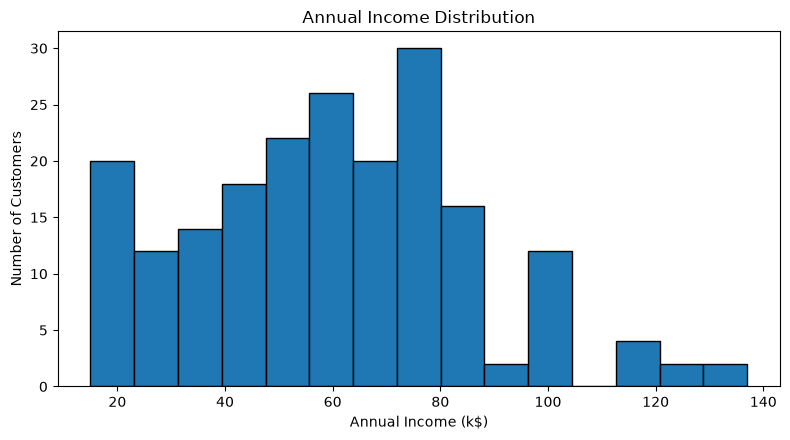

In [8]:
plt.figure(figsize=(8, 4.5))
plt.hist(
    df["Annual Income (k$)"],
    bins=15,
    edgecolor="black"
)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Spending score distribution

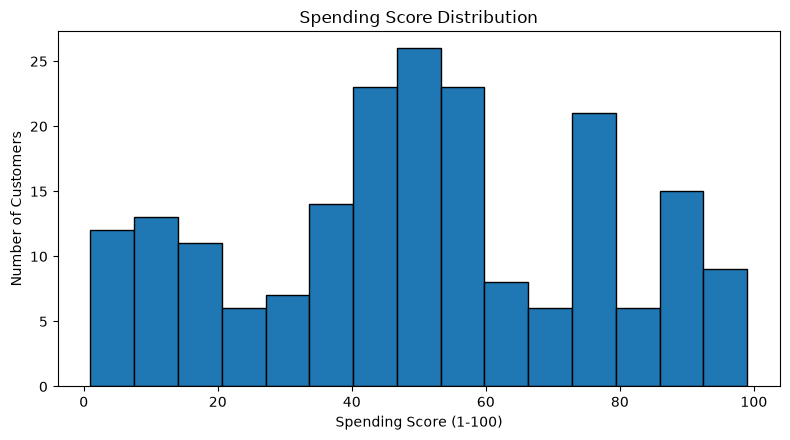

In [9]:
plt.figure(figsize=(8, 4.5))
plt.hist(
    df["Spending Score (1-100)"],
    bins=15,
    edgecolor="black"
)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Elbow method and silthouette score

In [10]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(
            X_scaled,
            labels
        )
    )

Elbow method

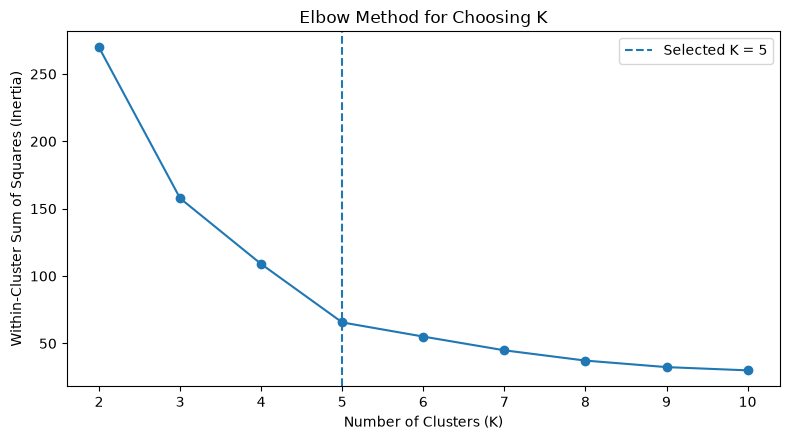

In [11]:
plt.figure(figsize=(8, 4.5))
plt.plot(
    list(k_values),
    inertias,
    marker="o"
)
plt.axvline(
    x=5,
    linestyle="--",
    label="Selected K = 5"
)
plt.title("Elbow Method for Choosing K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.xticks(list(k_values))
plt.legend()
plt.tight_layout()

plt.show()


Silthouette score

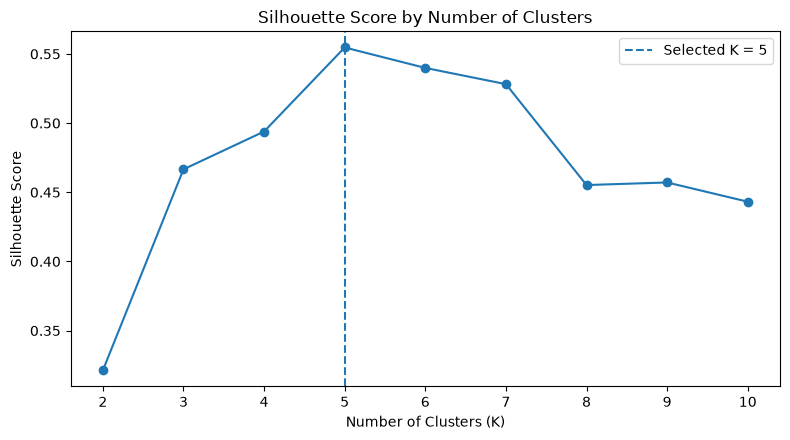

In [12]:
plt.figure(figsize=(8, 4.5))
plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)
plt.axvline(
    x=5,
    linestyle="--",
    label="Selected K = 5"
)
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.legend()
plt.tight_layout()
plt.show()

Evaluation table

In [13]:
evaluation = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette": silhouette_scores
})

print("\nClustering Evaluation:")
print(
    evaluation.round(3).to_string(index=False)
)


Clustering Evaluation:
 K  Inertia  Silhouette
 2  269.691       0.321
 3  157.704       0.467
 4  108.921       0.494
 5   65.568       0.555
 6   55.057       0.540
 7   44.865       0.528
 8   37.228       0.455
 9   32.392       0.457
10   29.982       0.443


Final K-means model

In [14]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Final silhouette score
final_silhouette = silhouette_score(
    X_scaled,
    df["Cluster"]
)
print("\nFinal K-Means Results")
print("Number of clusters:", 5)
print(
    "Silhouette Score:",
    round(final_silhouette, 3)
)
print(
    "Inertia:",
    round(kmeans.inertia_, 2)
)


Final K-Means Results
Number of clusters: 5
Silhouette Score: 0.555
Inertia: 65.57


Cluster centers

In [15]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)
centers_df = pd.DataFrame(
    centers,
    columns=features
)

Create meaningful cluster names

In [16]:
income_order = centers_df.sort_values(
    "Annual Income (k$)"
).index.tolist()

budget_clusters = income_order[:2]
middle_cluster = income_order[2]
high_income_clusters = income_order[3:]

budget_high_spend = max(
    budget_clusters,
    key=lambda c:
    centers_df.loc[
        c,
        "Spending Score (1-100)"
    ]
)

budget_low_spend = min(
    budget_clusters,
    key=lambda c:
    centers_df.loc[
        c,
        "Spending Score (1-100)"
    ]
)

high_income_high_spend = max(
    high_income_clusters,
    key=lambda c:
    centers_df.loc[
        c,
        "Spending Score (1-100)"
    ]
)

high_income_low_spend = min(
    high_income_clusters,
    key=lambda c:
    centers_df.loc[
        c,
        "Spending Score (1-100)"
    ]
)

cluster_names = {
    budget_high_spend:
        "Budget income / high spend",
    budget_low_spend:
        "Budget income / low spend",
    middle_cluster:
        "Mid income / balanced spend",
    high_income_high_spend:
        "High income / high spend",
    high_income_low_spend:
        "High income / low spend"
}

df["Segment"] = df["Cluster"].map(
    cluster_names
)
segment_order = [
    "Budget income / high spend",
    "Budget income / low spend",
    "Mid income / balanced spend",
    "High income / high spend",
    "High income / low spend"
]

Customer cluster visualization

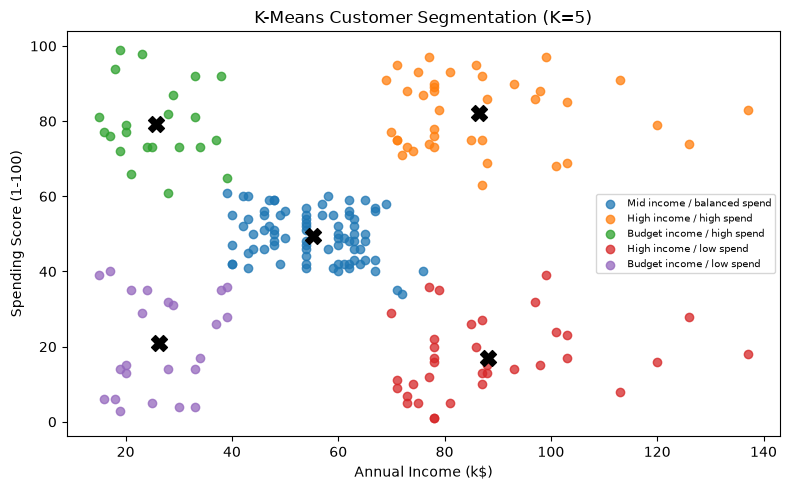

In [17]:
plt.figure(figsize=(8, 5))
for cluster in sorted(
    df["Cluster"].unique()
):
    subset = df[
        df["Cluster"] == cluster
    ]
    plt.scatter(
        subset["Annual Income (k$)"],
        subset["Spending Score (1-100)"],
        label=cluster_names[cluster],
        alpha=0.75
    )

# Plot cluster centers
for cluster_id, center in centers_df.iterrows():
    plt.scatter(
        center["Annual Income (k$)"],
        center["Spending Score (1-100)"],
        marker="X",
        s=130,
        color="black"
    )

plt.title(
    "K-Means Customer Segmentation (K=5)"
)
plt.xlabel("Annual Income (k$)")
plt.ylabel(
    "Spending Score (1-100)"
)
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()


Customer per cluster

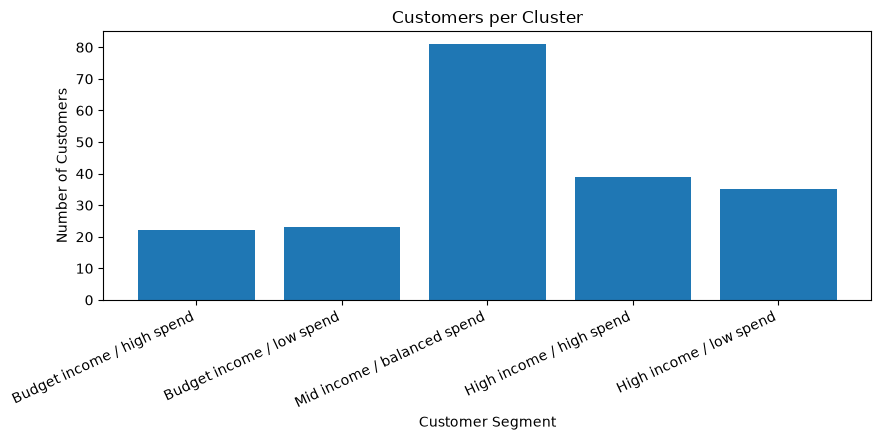

In [18]:
cluster_counts = (
    df["Segment"]
    .value_counts()
    .reindex(
        segment_order,
        fill_value=0
    )
)

plt.figure(figsize=(9, 4.5))
plt.bar(
    cluster_counts.index,
    cluster_counts.values
)
plt.title("Customers per Cluster")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(
    rotation=25,
    ha="right"
)
plt.tight_layout()
plt.show()

Cluster profile table

In [19]:
profiles = (
    df.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Age=("Age", "mean"),
        Avg_Income=(
            "Annual Income (k$)",
            "mean"
        ),
        Avg_Spending=(
            "Spending Score (1-100)",
            "mean"
        )
    )
    .reindex(segment_order)
)

print("\nCustomer Cluster Profiles:")
print(
    profiles.round(1)
    .to_string()
)
profiles.to_csv(
    "cluster_profiles.csv"
)



Customer Cluster Profiles:
                             Customers  Avg_Age  Avg_Income  Avg_Spending
Segment                                                                  
Budget income / high spend          22     25.3        25.7          79.4
Budget income / low spend           23     45.2        26.3          20.9
Mid income / balanced spend         81     42.7        55.3          49.5
High income / high spend            39     32.7        86.5          82.1
High income / low spend             35     41.1        88.2          17.1


Save clustered data

In [20]:
df.to_csv(
    "clustered_customers.csv",
    index=False
)

Relative cluster profile heatmap

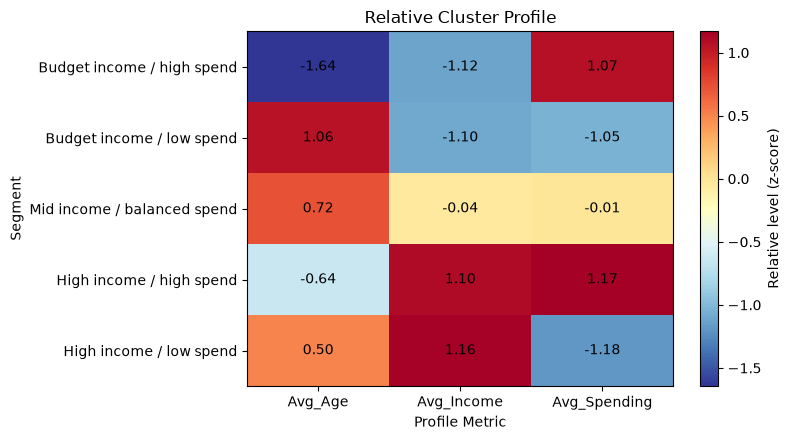

In [21]:
profile_metrics = profiles[
    [
        "Avg_Age",
        "Avg_Income",
        "Avg_Spending"
    ]
]

profile_std = (
    profile_metrics -
    profile_metrics.mean()
) / profile_metrics.std(ddof=0)

plt.figure(figsize=(8, 4.5))
image = plt.imshow(
    profile_std.values,
    cmap="RdYlBu_r",
    aspect="auto"
)
plt.colorbar(
    image,
    label="Relative level (z-score)"
)
plt.xticks(
    range(3),
    [
        "Avg_Age",
        "Avg_Income",
        "Avg_Spending"
    ]
)
plt.yticks(
    range(len(segment_order)),
    segment_order
)

# Display values inside heatmap
for i in range(
    profile_std.shape[0]
):
    for j in range(
        profile_std.shape[1]
    ):
        plt.text(
            j,
            i,
            f"{profile_std.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title(
    "Relative Cluster Profile"
)
plt.xlabel("Profile Metric")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()


Age vs spending score

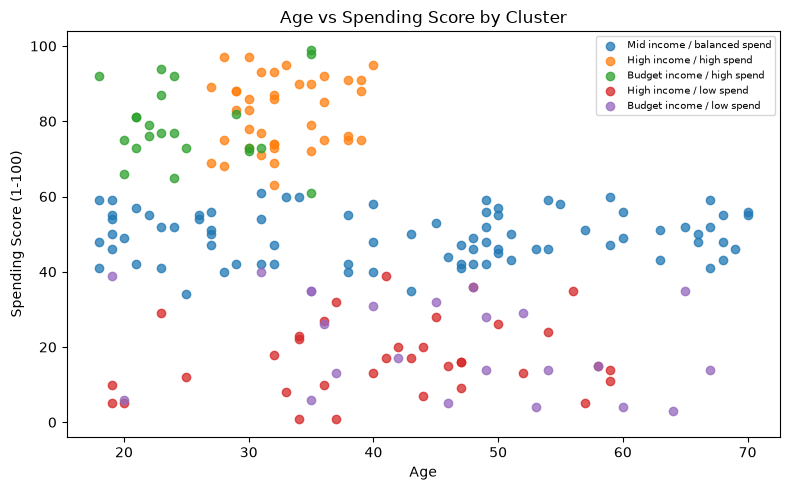


All analysis completed successfully.


In [22]:
plt.figure(figsize=(8, 5))
for cluster in sorted(
    df["Cluster"].unique()
):
    subset = df[
        df["Cluster"] == cluster
    ]
    plt.scatter(
        subset["Age"],
        subset["Spending Score (1-100)"],
        label=cluster_names[cluster],
        alpha=0.75
    )

plt.title(
    "Age vs Spending Score by Cluster"
)
plt.xlabel("Age")
plt.ylabel(
    "Spending Score (1-100)"
)
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

print("\nAll analysis completed successfully.")